In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model,  Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv2D, MaxPooling2D,
                                     GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam

# Configuration
image_size = (128, 128)
batch_size = 32
epochs_stage1 = 10
epochs_stage2 = 20
data_path = 'Eye_Diseases_Classifications'

# EarlyStopping Callback
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    data_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 3377 images belonging to 4 classes.
Found 841 images belonging to 4 classes.
Found 4218 images belonging to 4 classes.


In [4]:
from tensorflow.keras.models import load_model

In [5]:
print("Train class indices:", train_generator.class_indices)
print("Test class indices :", test_generator.class_indices)


Train class indices: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}
Test class indices : {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


In [6]:
mlp_model = Sequential([
    Flatten(input_shape=(128, 128, 3)),  
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

mlp_model.compile(optimizer=Adam(learning_rate=1e-4), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

history_mlp = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

mlp_model.save("eye_Model_MLP.h5")


C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.2801 - loss: 1.8280 - val_accuracy: 0.2913 - val_loss: 1.4315
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 71s 671ms/step - accuracy: 0.3003 - loss: 1.4386 - val_accuracy: 0.3234 - val_loss: 1.3427
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 71s 667ms/step - accuracy: 0.2994 - loss: 1.4485 - val_accuracy: 0.3341 - val_loss: 1.3855
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 66s 623ms/step - accuracy: 0.3109 - loss: 1.4210 - val_accuracy: 0.3044 - val_loss: 1.4568
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 68s 643ms/step - accuracy: 0.3115 - loss: 1.4629 - val_accuracy: 0.3793 - val_loss: 1.3418
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 615ms/step - accuracy: 0.3198 - loss: 1.4184 - val_accuracy: 0.3329 - val_loss: 1.3437
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 66s 620ms/step - accuracy: 0.3142 - loss: 1.4549 - val_accuracy: 0.3757 - val_loss: 1.3818
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 65s 610ms/step - accuracy: 0.3118 - loss: 1.4

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step


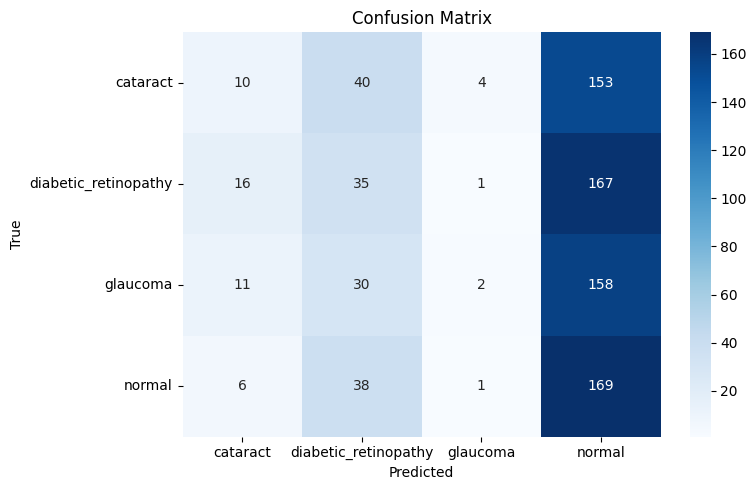

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.23      0.05      0.08       207
diabetic_retinopathy       0.24      0.16      0.19       219
            glaucoma       0.25      0.01      0.02       201
              normal       0.26      0.79      0.39       214

            accuracy                           0.26       841
           macro avg       0.25      0.25      0.17       841
        weighted avg       0.25      0.26      0.17       841



In [7]:
from tensorflow.keras.models import load_model

mlp_model = load_model("eye_Model_MLP.h5")



# Predictions
Y_pred = mlp_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [8]:
loss, acc = mlp_model.evaluate(val_generator)
print(f"Validation Accuracy: {acc:.4f}, Validation Loss: {loss:.4f}")
    

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 289ms/step - accuracy: 0.3424 - loss: 1.3559
Validation Accuracy: 0.3424, Validation Loss: 1.3559


In [9]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=1e-4), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

cnn_model.save("eye_Model_CNN.h5")


C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 82s 746ms/step - accuracy: 0.3340 - loss: 1.3436 - val_accuracy: 0.3579 - val_loss: 1.3193
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 718ms/step - accuracy: 0.4078 - loss: 1.2696 - val_accuracy: 0.4221 - val_loss: 1.2644
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 78s 737ms/step - accuracy: 0.4460 - loss: 1.2325 - val_accuracy: 0.4090 - val_loss: 1.2751
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 75s 708ms/step - accuracy: 0.4640 - loss: 1.2060 - val_accuracy: 0.4114 - val_loss: 1.2707
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 77s 726ms/step - accuracy: 0.4916 - loss: 1.1649 - val_accuracy: 0.4566 - val_loss: 1.1909
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 77s 721ms/step - accuracy: 0.5135 - loss: 1.1117 - val_accuracy: 0.4364 - val_loss: 1.2107
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 77s 724ms/step - accuracy: 0.5416 - loss: 1.0640 - val_accuracy: 0.4923 - val_loss: 1.1391
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 76s 722ms/step - accuracy: 0.5508 - loss: 1

27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step


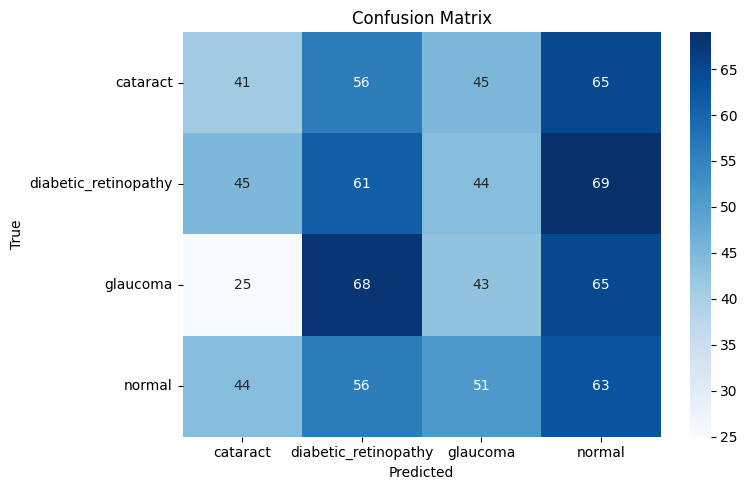

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.26      0.20      0.23       207
diabetic_retinopathy       0.25      0.28      0.27       219
            glaucoma       0.23      0.21      0.22       201
              normal       0.24      0.29      0.26       214

            accuracy                           0.25       841
           macro avg       0.25      0.25      0.25       841
        weighted avg       0.25      0.25      0.25       841



In [10]:
cnn_model = load_model("eye_Model_CNN.h5")


# Predictions
Y_pred = cnn_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [11]:
 #Base Model (Frozen)
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Top Model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile and Train (Stage 1)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Unfreeze some layers for fine-tuning (Stage 2)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Save the model
model.save("eye_Model_MobileNetV2_Improved.h5")


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 86s 740ms/step - accuracy: 0.6411 - loss: 1.0802 - val_accuracy: 0.6873 - val_loss: 0.9177
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 74s 695ms/step - accuracy: 0.7382 - loss: 0.8323 - val_accuracy: 0.7004 - val_loss: 0.8864
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 682ms/step - accuracy: 0.7533 - loss: 0.7723 - val_accuracy: 0.6766 - val_loss: 0.9146
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 74s 694ms/step - accuracy: 0.7699 - loss: 0.7364 - val_accuracy: 0.6897 - val_loss: 0.8916
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 683ms/step - accuracy: 0.7776 - loss: 0.6995 - val_accuracy: 0.7027 - val_loss: 0.8604
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 72s 680ms/step - accuracy: 0.7714 - loss: 0.7023 - val_accuracy: 0.7182 - val_loss: 0.8006
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 686ms/step - accuracy: 0.7951 - loss: 0.6431 - val_accuracy: 0.6885 - val_loss: 0.8716
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 689ms/step - accuracy: 0.8004 - loss: 0

132/132 ━━━━━━━━━━━━━━━━━━━━ 58s 424ms/step


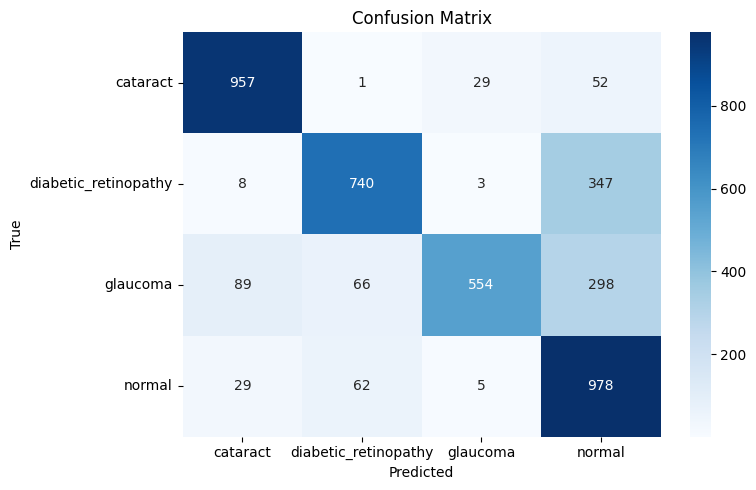

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.88      0.92      0.90      1039
diabetic_retinopathy       0.85      0.67      0.75      1098
            glaucoma       0.94      0.55      0.69      1007
              normal       0.58      0.91      0.71      1074

            accuracy                           0.77      4218
           macro avg       0.81      0.76      0.76      4218
        weighted avg       0.81      0.77      0.76      4218



In [12]:
model = load_model("eye_Model_MobileNetV2_Improved.h5")

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [13]:
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0

In [14]:
# Base Model (Frozen)
base_model = VGG16(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Top Model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model_VGG = Model(inputs=base_model.input, outputs=output)

# Compile and Train (Stage 1)
model_VGG.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history1 = model_VGG.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Unfreeze some layers for fine-tuning (Stage 2)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model_VGG.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model_VGG.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Save the model
model_VGG.save("eye_Model_VGG16_Improved.h5")

Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.4803 - loss: 1.3031 - val_accuracy: 0.5945 - val_loss: 1.0865
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.6035 - loss: 1.0284 - val_accuracy: 0.6659 - val_loss: 0.9595
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 544s 5s/step - accuracy: 0.6426 - loss: 0.9522 - val_accuracy: 0.6611 - val_loss: 0.9175
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.6678 - loss: 0.8912 - val_accuracy: 0.6647 - val_loss: 0.9103
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6903 - loss: 0.8644 - val_accuracy: 0.6706 - val_loss: 0.8727
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.6962 - loss: 0.8320 - val_accuracy: 0.6587 - val_loss: 0.8990
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6959 - loss: 0.8191 - val_accuracy: 0.6706 - val_loss: 0.8722
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.6997 - loss: 0.8110 - val_accu

132/132 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step


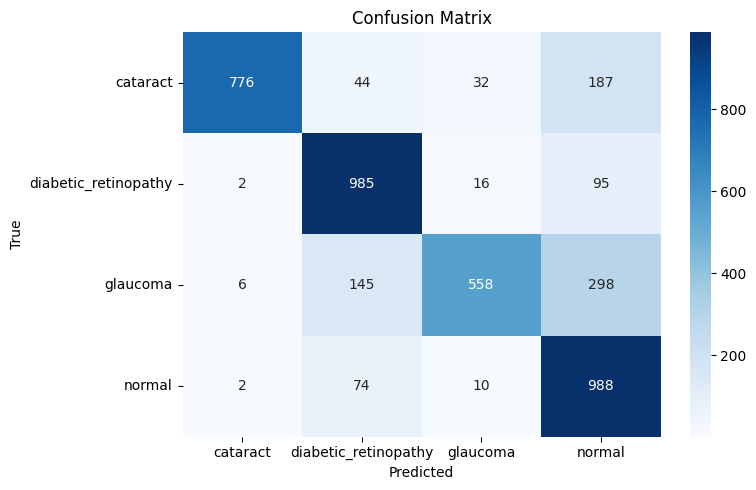

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.99      0.75      0.85      1039
diabetic_retinopathy       0.79      0.90      0.84      1098
            glaucoma       0.91      0.55      0.69      1007
              normal       0.63      0.92      0.75      1074

            accuracy                           0.78      4218
           macro avg       0.83      0.78      0.78      4218
        weighted avg       0.83      0.78      0.78      4218



In [15]:
vgg_model = load_model("eye_Model_VGG16_Improved.h5")

Y_pred = vgg_model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [16]:

# Base Model (Frozen)
base_model = ResNet50(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Top Model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model_ResNet = Model(inputs=base_model.input, outputs=output)

# Compile and Train (Stage 1)
model_ResNet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history1 = model_ResNet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Unfreeze some layers for fine-tuning (Stage 2)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model_ResNet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model_ResNet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Save the model
model_ResNet.save("eye_Model_ResNet50_Improved.h5")


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 115s 992ms/step - accuracy: 0.3133 - loss: 1.4338 - val_accuracy: 0.3746 - val_loss: 1.3515
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 394s 4s/step - accuracy: 0.3636 - loss: 1.3333 - val_accuracy: 0.3175 - val_loss: 1.3748
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 101s 949ms/step - accuracy: 0.3687 - loss: 1.3333 - val_accuracy: 0.3436 - val_loss: 1.3598
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 375s 4s/step - accuracy: 0.3823 - loss: 1.3294 - val_accuracy: 0.3567 - val_loss: 1.3496
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 101s 953ms/step - accuracy: 0.3796 - loss: 1.3181 - val_accuracy: 0.3246 - val_loss: 1.3779
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 699s 7s/step - accuracy: 0.3808 - loss: 1.3279 - val_accuracy: 0.3520 - val_loss: 1.3377
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 103s 976ms/step - accuracy: 0.3894 - loss: 1.3180 - val_accuracy: 0.3555 - val_loss: 1.3466
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 104s 977ms/step - accuracy: 0.3894 - loss: 1.

132/132 ━━━━━━━━━━━━━━━━━━━━ 107s 784ms/step


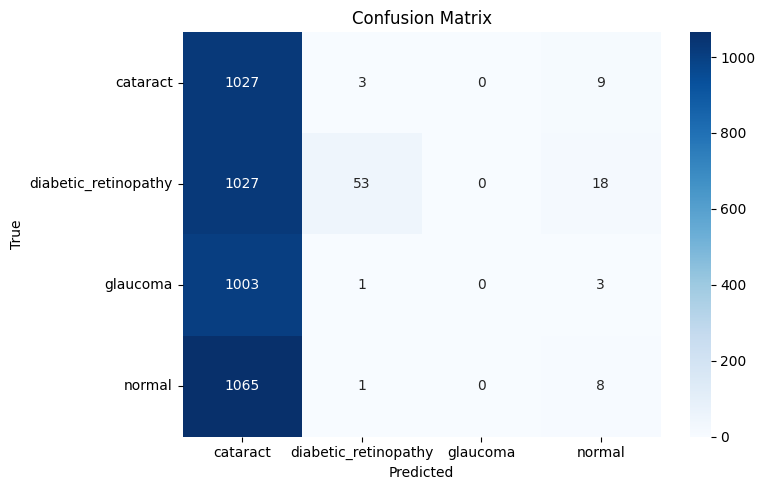

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.25      0.99      0.40      1039
diabetic_retinopathy       0.91      0.05      0.09      1098
            glaucoma       0.00      0.00      0.00      1007
              normal       0.21      0.01      0.01      1074

            accuracy                           0.26      4218
           macro avg       0.34      0.26      0.13      4218
        weighted avg       0.35      0.26      0.13      4218



C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [17]:
resnet_model = load_model("eye_Model_ResNet50_Improved.h5")


# Predictions
Y_pred = resnet_model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

In [18]:
 #Base Model (Frozen)
base_model = EfficientNetB0(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Top Model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model_EfficientNet = Model(inputs=base_model.input, outputs=output)

# Compile and Train (Stage 1)
model_EfficientNet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history1 = model_EfficientNet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage1,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Unfreeze some layers for fine-tuning (Stage 2)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model_EfficientNet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model_EfficientNet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs_stage2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

# Save the model
model_EfficientNet.save("eye_Model_EfficientNetB0_Improved.h5")


Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 93s 710ms/step - accuracy: 0.2425 - loss: 1.5311 - val_accuracy: 0.2604 - val_loss: 1.4688
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 52s 491ms/step - accuracy: 0.2467 - loss: 1.4552 - val_accuracy: 0.2604 - val_loss: 1.4385
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 52s 494ms/step - accuracy: 0.2410 - loss: 1.4289 - val_accuracy: 0.2604 - val_loss: 1.4227
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 51s 484ms/step - accuracy: 0.2550 - loss: 1.4149 - val_accuracy: 0.2604 - val_loss: 1.4083
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 512ms/step - accuracy: 0.2425 - loss: 1.4049 - val_accuracy: 0.2390 - val_loss: 1.4009
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 50s 474ms/step - accuracy: 0.2384 - loss: 1.3983 - val_accuracy: 0.2390 - val_loss: 1.3961
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 50s 472ms/step - accuracy: 0.2372 - loss: 1.3949 - val_accuracy: 0.2604 - val_loss: 1.3947
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 50s 469ms/step - accuracy: 0.2384 - loss: 1

132/132 ━━━━━━━━━━━━━━━━━━━━ 45s 335ms/step


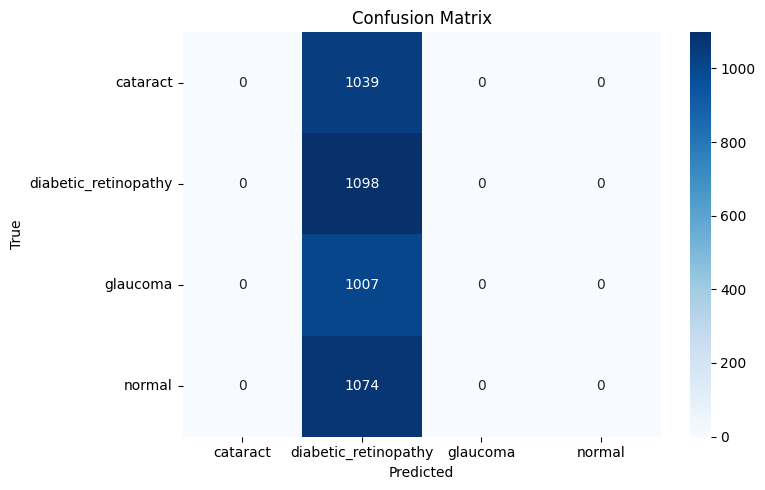

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.00      0.00      0.00      1039
diabetic_retinopathy       0.26      1.00      0.41      1098
            glaucoma       0.00      0.00      0.00      1007
              normal       0.00      0.00      0.00      1074

            accuracy                           0.26      4218
           macro avg       0.07      0.25      0.10      4218
        weighted avg       0.07      0.26      0.11      4218



C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\soniya s\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [19]:
eff_model = load_model("eye_Model_EfficientNetB0_Improved.h5")

# Predictions
Y_pred = eff_model.predict(test_generator)

y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [20]:
from tensorflow.keras.models import load_model

model_trasfer = load_model("eye_Model_MobileNetV2_Improved.h5")


eff_model = load_model("eye_Model_EfficientNetB0_Improved.h5")


resnet_model = load_model("eye_Model_ResNet50_Improved.h5")


vgg_model = load_model("eye_Model_VGG16_Improved.h5")


cnn_model = load_model("eye_Model_CNN.h5")


mlp_model = load_model("eye_Model_MLP.h5")


In [21]:
from tensorflow.keras.preprocessing import image

def predict_image(model, image_Path, class_indices, target_size = (128, 128)):
    img = image.load_img(image_Path, target_size = target_size)
    img_array = image.img_to_array(img)/255.0    #converting to numpy array and resizing it 
    img_array = np.expand_dims(img_array, axis = 0) #Shape:(1, height, width, Channel)
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_index]


    class_labels = {v:k for k,v in class_indices.items()}
    predicted_class = class_labels[predicted_index]

    print(f"Predicted class : {predicted_class}, confidence_score : {confidence:.2f}")
    return predicted_class, confidence


In [26]:
models = {
    "VGG16": vgg_model,
}
for name, model in models.items():
    print(f" {name}  :  ")
    predict_image(model,r"C:\Users\soniya s\Soniya S\Mini projects\Eye_Diseases_Classifications\cataract\_0_4015166.jpg",val_generator.class_indices)
    print("\n\n\n")

 VGG16  :  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicted class : cataract, confidence_score : 0.99




